In [1]:
# type: ignore
# Has multi-dimensional arrays and matrices.
# Has a large collection of mathematical functions to operate on these arrays.
import numpy as np

# Data manipulation and analysis.
import pandas as pd

# Data visualization tools.
import seaborn as sns

# Agent functionality
import mesa

from mesa.discrete_space import Cell, CellAgent, OrthogonalMooreGrid

import random

import time

from matplotlib.colors import ListedColormap

In [2]:
# type: ignore
class DirtyCell(Cell):
    def __init__(self, coordinate, capacity, random, dirty_percentage):
        super().__init__(coordinate, capacity, random)
        self.isClean = True if random.randint(1, 100) > dirty_percentage else False 

In [3]:
# type: ignore
class CleaningAgent(CellAgent):
    
    def __init__(self, model, cell):     
        super().__init__(model)
        self.cell = cell
        self.move_counter = 0

    def move(self):
        neighbors = list(self.cell.neighborhood.cells)

        empty_neighbors = [
            cell for cell in neighbors
            if len(cell.agents) == 0
        ]

        if empty_neighbors:
            self.cell = random.choice(empty_neighbors)
            self.move_counter += 1

    def clean_cell(self):
        self.cell.isClean = True

In [4]:
# type: ignore
"""
Modelo de limpieza con agentes que se mueven y limpian celdas sucias. 
"""

class CleaningModel(mesa.Model):
    
    def __init__(self, n, width, height, dirty_percentage, seed=None):
        super().__init__(seed=seed)
        self.num_agents = n
        self.dirty_percentage = dirty_percentage

        class DirtyCellWithPercentage(DirtyCell):
            def __init__(self, coordinate, capacity, random):
                super().__init__(coordinate, capacity, random, dirty_percentage)
        
        self.grid = OrthogonalMooreGrid(
            (width, height), 
            torus=True, 
            capacity=100, 
            random=self.random, 
            cell_klass=DirtyCellWithPercentage
        )

        initial_cell = self.grid[(1,1)]

        agents = CleaningAgent.create_agents(
            self,
            self.num_agents,
            [initial_cell] * self.num_agents
        )

    def step(self):
        self.agents.do("move")
        self.agents.do("clean_cell")

In [5]:
n_agents = 70
width = 20
height = 20
dirty_percentage = 60
model = CleaningModel(n=n_agents, width=width, height=height, dirty_percentage=dirty_percentage)

In [6]:
# type: ignore

"""
Aquí se corre el modelo hasta que todas las celdas estén limpias o hasta que se alcance el tiempo máximo permitido.
Al finalizar, se imprime el resultado y el número de movimientos realizados por cada agente.
"""

max_time = 0.01  # segundos
start_time = time.time()
step_count = 0

while (time.time() - start_time) < max_time:
    model.step()
    step_count += 1
    
    # Verificar si todas las celdas están limpias
    all_clean = all(cell.isClean for cell in model.grid.all_cells)
    if all_clean:
        elapsed = time.time() - start_time
        print(f"✓ Todas las celdas limpias en {step_count} pasos ({elapsed:.2f}s)")
        # Imprimir número de movimientos por agente
        for i, agent in enumerate(model.agents):
            print(f"  - Agente {i+1}: {agent.move_counter} movimientos")
        break
else:
    dirty_cells = sum(1 for cell in model.grid.all_cells if not cell.isClean)
    percentage = (dirty_cells / (width * height)) * 100
    print(f"Tiempo máximo alcanzado ({max_time}s). Quedan {dirty_cells} celdas sucias (un {percentage:.2f} % del total)")
    # Imprimir número de movimientos por agente
    for i, agent in enumerate(model.agents):
        print(f"  - Agente {i+1}: {agent.move_counter} movimientos")

Tiempo máximo alcanzado (0.01s). Quedan 105 celdas sucias (un 26.25 % del total)
  - Agente 1: 19 movimientos
  - Agente 2: 19 movimientos
  - Agente 3: 19 movimientos
  - Agente 4: 19 movimientos
  - Agente 5: 19 movimientos
  - Agente 6: 19 movimientos
  - Agente 7: 19 movimientos
  - Agente 8: 19 movimientos
  - Agente 9: 18 movimientos
  - Agente 10: 18 movimientos
  - Agente 11: 18 movimientos
  - Agente 12: 17 movimientos
  - Agente 13: 17 movimientos
  - Agente 14: 17 movimientos
  - Agente 15: 17 movimientos
  - Agente 16: 17 movimientos
  - Agente 17: 17 movimientos
  - Agente 18: 17 movimientos
  - Agente 19: 16 movimientos
  - Agente 20: 16 movimientos
  - Agente 21: 16 movimientos
  - Agente 22: 16 movimientos
  - Agente 23: 15 movimientos
  - Agente 24: 15 movimientos
  - Agente 25: 15 movimientos
  - Agente 26: 15 movimientos
  - Agente 27: 15 movimientos
  - Agente 28: 14 movimientos
  - Agente 29: 13 movimientos
  - Agente 30: 14 movimientos
  - Agente 31: 14 movimiento

[Text(0.5, 1.0, 'Number of agents on each cell of the grid')]

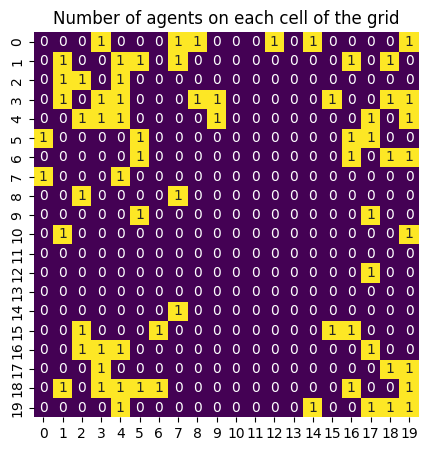

In [7]:
# type: ignore
agent_counts = np.zeros((model.grid.width, model.grid.height))

for cell in model.grid.all_cells:
    agent_counts[cell.coordinate] = len(cell.agents)

g = sns.heatmap(agent_counts, cmap="viridis", annot=True, cbar=False, square=True)
g.figure.set_size_inches(5, 5)
g.set(title="Number of agents on each cell of the grid")

Text(113.9222222222222, 0.5, 'Fila')

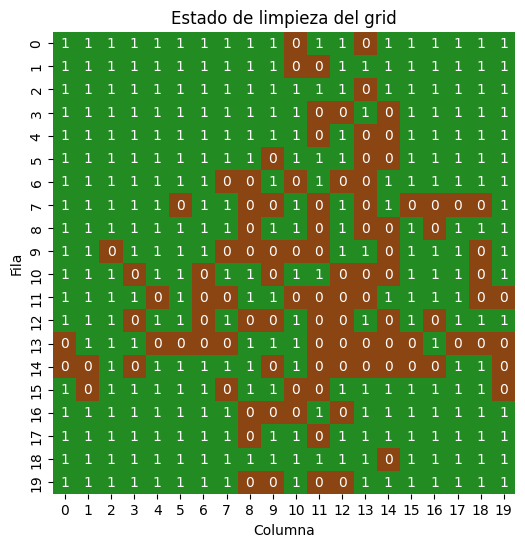

In [8]:
# type: ignore
clean_status = np.zeros((model.grid.width, model.grid.height))

for cell in model.grid.all_cells:
    clean_status[cell.coordinate] = 1 if cell.isClean else 0

colors = ['#8B4513', '#228B22']
cmap = ListedColormap(colors)

# Plot usando seaborn
g = sns.heatmap(
    clean_status, 
    cmap=cmap,
    annot=True, 
    square=True,
    vmin=0,
    vmax=1,
    cbar=False
)
g.figure.set_size_inches(7, 6)
g.set(title="Estado de limpieza del grid")
g.set_xlabel("Columna")
g.set_ylabel("Fila")